### Validálás

#### Légúti kit PCR görbe tesztadatok

In [2]:
from app.pcr.data_loader import eds_extract

covid_01 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_01.eds"
covid_02 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_02.eds"
covid_03 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_03.eds"
covid_04 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_04.eds"
covid_05 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_05.eds"
covid_06 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_06.eds"
covid_07 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_07.eds"
covid_08 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_08.eds"
covid_09 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_09.eds"
covid_10 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_10.eds"
hpv_1 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV\\2015-08-13_kereszt kontam_ism2_plate1_csop1.eds"
df = eds_extract(covid_01)
print(df.head())



dye  well well_position  cycle    CY5    FAM    ROX    VIC
0       1            A1      1  63745  68319  49989  72140
1       1            A1      2  63621  68203  49859  71899
2       1            A1      3  63501  67822  49828  71490
3       1            A1      4  63504  67657  49967  71383
4       1            A1      5  63584  67787  50038  71346


In [3]:
import numpy as np
from scipy.signal import savgol_filter

 
def evaluate_sample_new(cycles,
                 fluorescence,
                 plateau_cycles: int = 10,
                 plateau_std_factor: float = 2.0,
                 dy_mean_threshold: float = 1000.0,
                 window: int = 9,
                 poly: int = 2) -> dict:
    """
    Cycle of Plateau Deviation (CpD) módszer alapján meghatározza,
    hogy egy PCR görbe pozitív vagy negatív, és kiszámolja a Ct értéket.
 
    Negatív/pozitív döntés:
        A simított görbe 1. deriváltjának átlaga meghaladja-e a küszöböt?
        Ha igen → pozitív, visszafelé haladva meghatározza a Ct-t.
        Ha nem  → negatív.
 
    Paraméterek
    -----------
    cycles             : ciklusszámok tömbje (x tengely)
    fluorescence       : fluoreszcencia értékek tömbje (y tengely)
    plateau_cycles     : hány utolsó ciklust használjon plateau-hoz (default: 10)
    plateau_std_factor : hány szórásnyira kell kilépni a plateau-ból (default: 2)
    dy_mean_threshold  : minimális derivált átlag pozitív döntéshez (default: 1000)
    window             : Savitzky-Golay ablakméret (default: 9)
    poly               : Savitzky-Golay polinom fok (default: 2)
 
    Visszatérési érték
    ------------------
    dict:
        result  : "pozitív" vagy "negatív"
        ct      : Ct érték (float), vagy None ha negatív
    """
 
    y_smooth = savgol_filter(fluorescence, window, poly)
    dy = savgol_filter(y_smooth, window, poly, deriv=1)
    dy_mean = dy.mean()
    return dy_mean

In [4]:
import pandas as pd

files = [covid_01, covid_02, covid_03, covid_04, covid_05, covid_06, covid_07, covid_08, covid_09, covid_10]

all_result = pd.DataFrame()
for file in files:
    df = eds_extract(file)
    rows = []
    channels = ["FAM", "VIC", "CY5", "ROX"]

    for wp in df['well_position'].unique():
        wp_df = df[df['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_new(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result['PCR'] = file.split("\\")[-1].split(".")[0]
    all_result = pd.concat([all_result, result], ignore_index=True)

all_result.head()

,well_position,FAM,VIC,CY5,ROX,PCR
0,A1,-64.914202,1536.127813,154.325537,297.587277,covid_01
1,A11,-75.514159,1718.092690,145.157051,294.564519,covid_01
2,A13,-50.864883,1569.107503,150.624639,286.718197,covid_01
3,A15,-74.851208,1660.808902,138.308082,288.291042,covid_01
4,A17,-42.495349,1547.689848,137.867387,272.201084,covid_01


In [5]:
all_result_melted = all_result.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_mean')
all_result_melted.head()

,PCR,well_position,dye,dy_mean
0,covid_01,A1,FAM,-64.914202
1,covid_01,A11,FAM,-75.514159
2,covid_01,A13,FAM,-50.864883
3,covid_01,A15,FAM,-74.851208
4,covid_01,A17,FAM,-42.495349


#### Légúti kit minta tesztadatok

In [6]:
leguti_file = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260426_sample_results_leguti.xlsx"
leguti_sample = pd.read_excel(leguti_file)
kizárandó = ['Valid NTC', 'Valid PK', 'Valid PrepNTC']
leguti_sample = leguti_sample[~leguti_sample['minta'].isin(kizárandó)]

#### HPV kit PCR-görbe tesztadatok

In [7]:
from app.pcr.data_loader import eds_extract


hpv_1 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_1.eds"
hpv_2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_2.eds"
hpv_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_3.eds"
hpv_4 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_4.eds"
hpv_5 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_5.eds"
hpv_6 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_6.eds"
hpv_7 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_7.eds"
hpv_df = eds_extract(hpv_2)
hpv_df.to_excel("C:\\Users\\anett\\Downloads\\hpv_teszt_2.xlsx", index=False)
print(hpv_df.head())

dye  well well_position  cycle    CY5     FAM     VIC
0       1            A1      1  33294  365294  262174
1       1            A1      2  32800  362112  259326
2       1            A1      3  31772  356887  254004
3       1            A1      4  30616  347854  247097
4       1            A1      5  29532  336745  239351


In [8]:
import pandas as pd


hpv_files = [hpv_1, hpv_2, hpv_3, hpv_4, hpv_5, hpv_6, hpv_7]
#hpv_files = [hpv_3]

all_result_hpv = pd.DataFrame()
for hpv_file in hpv_files:
    df_hpv = eds_extract(hpv_file)
    rows = []
    channels = ["FAM", "VIC", "CY5"]

    for wp in df_hpv['well_position'].unique():
        wp_df = df_hpv[df_hpv['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_new(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result_hpv = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result_hpv['PCR'] = hpv_file.split("\\")[-1].split(".")[0]
    all_result_hpv = pd.concat([all_result_hpv, result_hpv], ignore_index=True)

all_result_hpv.head()


,well_position,FAM,VIC,CY5,PCR
0,A1,-115.592540,9559.730553,333.041545,hpv_teszt_1
1,A11,-191.774842,16.804564,4698.660089,hpv_teszt_1
2,A13,202.579321,11235.075068,520.109517,hpv_teszt_1
3,A15,15.528237,-26.968991,4551.419058,hpv_teszt_1
4,A17,-781.406693,8979.387175,159.595352,hpv_teszt_1


In [9]:
all_result_hpv_melted = all_result_hpv.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_mean')

#### HPV kit minta tesztadatok

In [10]:
hpv_file = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260426_sample_results_hpv.xlsx"
hpv_sample = pd.read_excel(hpv_file)
kizárandó = ['Valid NTC', 'Valid PK', 'Valid PrepNTC']
hpv_sample = hpv_sample[~hpv_sample['minta'].isin(kizárandó)]

### Kóczi

### Légúti kit - PCR görbék

In [11]:
leguti_koczi = pd.read_excel(r"C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260502_manulis_ertekeles_leguti_koczi.xlsx")
leguti_koczi_curves = leguti_koczi.drop(columns=["minta", "target"], axis=1)
leguti_koczi_curves_melted = leguti_koczi_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="manual_result")
leguti_koczi_curves_melted.head()

,well_position,PCR,dye,manual_result
0,A1,covid_10,FAM,negatív
1,A3,covid_10,FAM,negatív
2,A5,covid_10,FAM,negatív
3,A7,covid_10,FAM,negatív
4,A9,covid_10,FAM,negatív


In [12]:
all_curves_leguti_koczi = pd.merge(all_result_melted, leguti_koczi_curves_melted, on=["PCR", "well_position", "dye"], how="left")
threshold = 1000
all_curves_leguti_koczi['predikcio'] = np.where(all_curves_leguti_koczi['dy_mean'] > threshold, 'pozitív', 'negatív')
all_curves_leguti_koczi.head()

,PCR,well_position,dye,dy_mean,manual_result,predikcio
0,covid_01,A1,FAM,-64.914202,negatív,negatív
1,covid_01,A11,FAM,-75.514159,negatív,negatív
2,covid_01,A13,FAM,-50.864883,negatív,negatív
3,covid_01,A15,FAM,-74.851208,negatív,negatív
4,covid_01,A17,FAM,-42.495349,negatív,negatív


In [13]:
all_curves_leguti_koczi[all_curves_leguti_koczi['manual_result'] != all_curves_leguti_koczi['predikcio'] ]

,PCR,well_position,dye,dy_mean,manual_result,predikcio
433,covid_06,M19,FAM,1031.578325,negatív,pozitív
1993,covid_06,M19,CY5,1254.354043,negatív,pozitív
2773,covid_06,M19,ROX,1054.252412,negatív,pozitív


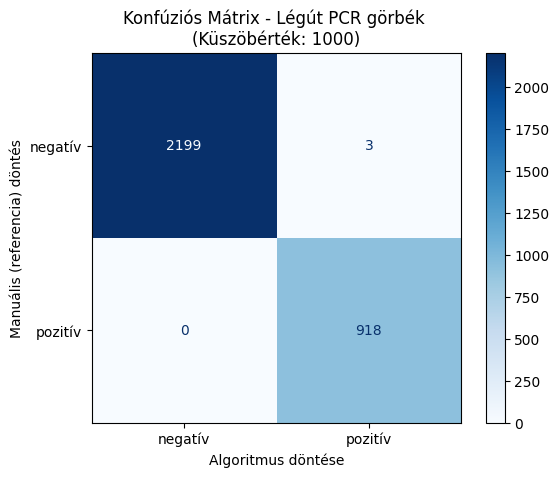

In [14]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív']
leguti_koczi_cm = confusion_matrix(all_curves_leguti_koczi['manual_result'], all_curves_leguti_koczi['predikcio'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=leguti_koczi_cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues) # Zöld színskála a diagnosztikai siker jelzésére
plt.title(f'Konfúziós Mátrix - Légút PCR görbék \n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_hpv.png')
plt.show()


In [15]:
tn, fp, fn, tp = leguti_koczi_cm.ravel()

# Számítások
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"Szenzitivitás: {sensitivity:.2%}")
print(f"Specificitás: {specificity:.2%}")
print(f"Pontosság: {accuracy:.2%}")
print(f"PPV (Pozitív prediktív érték): {ppv:.2%}")
print(f"NPV (Negatív prediktív érték): {npv:.2%}")

Szenzitivitás: 100.00%
Specificitás: 99.86%
Pontosság: 99.90%
PPV (Pozitív prediktív érték): 99.67%
NPV (Negatív prediktív érték): 100.00%


### Légúti kit - Minták

In [16]:
manual_sample_leguti_koczi = leguti_koczi[['PCR', 'well_position', 'minta', 'target']]
manual_sample_leguti_koczi = manual_sample_leguti_koczi.query("minta != 'kontroll'")
manual_sample_leguti_koczi.head()

,PCR,well_position,minta,target
0,covid_10,A1,negatív,NaN
1,covid_10,A3,negatív,NaN
2,covid_10,A5,negatív,NaN
3,covid_10,A7,negatív,NaN
4,covid_10,A9,negatív,NaN


In [17]:
all_samples_leguti_koczi = pd.merge(leguti_sample, manual_sample_leguti_koczi, on=["PCR", "well_position"], how="left",suffixes=('', '_manual'))
all_samples_leguti_koczi.head()

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
0,covid_01,1,A1,negatív,NaN,NaN,negatív,NaN
1,covid_01,3,A3,negatív,NaN,NaN,negatív,NaN
2,covid_01,5,A5,negatív,NaN,NaN,negatív,NaN
3,covid_01,7,A7,negatív,NaN,NaN,negatív,NaN
4,covid_01,9,A9,negatív,NaN,NaN,negatív,NaN


In [18]:
all_samples_leguti_koczi[all_samples_leguti_koczi['minta'] != all_samples_leguti_koczi['minta_manual'] ]

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
418,covid_06,307,M19,pozitív,Influenza A és B,manuális értékelést igényel,negatív,NaN


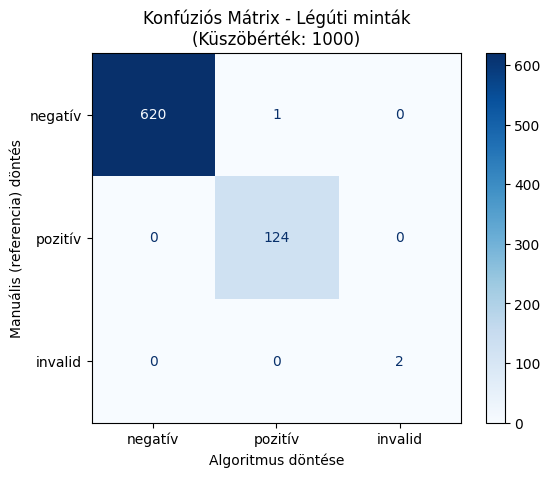

In [19]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív', 'invalid']
leguti_sample_koczi_cm = confusion_matrix(all_samples_leguti_koczi['minta_manual'], all_samples_leguti_koczi['minta'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=leguti_sample_koczi_cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues) 
plt.title(f'Konfúziós Mátrix - Légúti minták\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_leguti_samples.png')
plt.show()

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(all_samples_leguti_koczi['minta_manual'], all_samples_leguti_koczi['minta'], 
      labels=["invalid", "negatív", "pozitív"], digits=3))


              precision    recall  f1-score   support

     invalid      1.000     1.000     1.000         2
     negatív      1.000     0.998     0.999       621
     pozitív      0.992     1.000     0.996       124

    accuracy                          0.999       747
   macro avg      0.997     0.999     0.998       747
weighted avg      0.999     0.999     0.999       747



### HPV kit - PCR görbék

In [21]:
hpv_koczi = pd.read_excel(r"C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260504_manulis_ertekeles_hpv_Koczi.xlsx")
hpv_koczi_curves = hpv_koczi.drop(columns=["minta", "target"], axis=1)
hpv_koczi_curves_melted = hpv_koczi_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="manual_result")
hpv_koczi_curves_melted.head()

,well_position,PCR,dye,manual_result
0,A1,hpv_teszt_1,FAM,negatív
1,A11,hpv_teszt_1,FAM,negatív
2,A13,hpv_teszt_1,FAM,negatív
3,A15,hpv_teszt_1,FAM,negatív
4,A17,hpv_teszt_1,FAM,negatív


In [22]:
all_hpv_curves_koczi = pd.merge(all_result_hpv_melted, hpv_koczi_curves_melted, on=["PCR", "well_position", "dye"], how="left")
threshold = 1000
all_hpv_curves_koczi['predikcio'] = np.where(all_hpv_curves_koczi['dy_mean'] > threshold, 'pozitív', 'negatív')
all_hpv_curves_koczi.head()


,PCR,well_position,dye,dy_mean,manual_result,predikcio
0,hpv_teszt_1,A1,FAM,-115.592540,negatív,negatív
1,hpv_teszt_1,A11,FAM,-191.774842,negatív,negatív
2,hpv_teszt_1,A13,FAM,202.579321,negatív,negatív
3,hpv_teszt_1,A15,FAM,15.528237,negatív,negatív
4,hpv_teszt_1,A17,FAM,-781.406693,negatív,negatív


In [23]:
all_hpv_curves_koczi[all_hpv_curves_koczi['predikcio'] != all_hpv_curves_koczi['manual_result']]

,PCR,well_position,dye,dy_mean,manual_result,predikcio
1464,hpv_teszt_2,E1,CY5,1002.629864,negatív,pozitív
1530,hpv_teszt_2,O21,CY5,1253.821060,negatív,pozitív


In [24]:
all_hpv_curves_koczi[all_hpv_curves_koczi['well_position'] == 'C13']

,PCR,well_position,dye,dy_mean,manual_result,predikcio
14,hpv_teszt_1,C13,FAM,106.837261,negatív,negatív
110,hpv_teszt_2,C13,FAM,89.652733,negatív,negatív
206,hpv_teszt_3,C13,FAM,100.891420,negatív,negatív
302,hpv_teszt_4,C13,FAM,180.359778,negatív,negatív
398,hpv_teszt_5,C13,FAM,223.123992,negatív,negatív
494,hpv_teszt_6,C13,FAM,63.009905,negatív,negatív
590,hpv_teszt_7,C13,FAM,402.829812,negatív,negatív
686,hpv_teszt_1,C13,VIC,92.722034,negatív,negatív
782,hpv_teszt_2,C13,VIC,84.090798,negatív,negatív
878,hpv_teszt_3,C13,VIC,909.390643,negatív,negatív


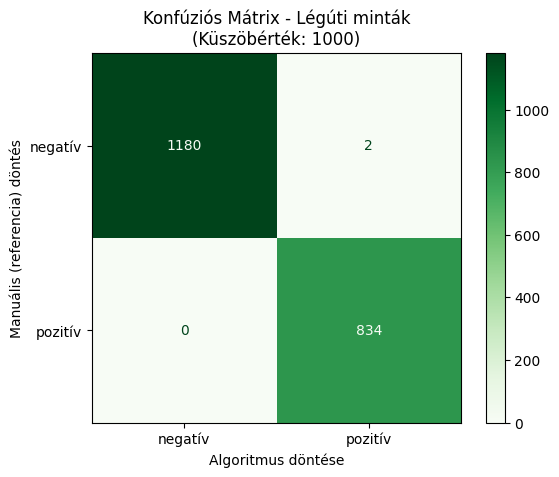

In [25]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív']
hpv_koczi_cm = confusion_matrix(all_hpv_curves_koczi['manual_result'], all_hpv_curves_koczi['predikcio'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=hpv_koczi_cm, display_labels=labels)
disp.plot(cmap=plt.cm.Greens) 
plt.title(f'Konfúziós Mátrix - Légúti minták\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_leguti_samples.png')
plt.show()


In [26]:
tn, fp, fn, tp = hpv_koczi_cm.ravel()

# Számítások
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"Szenzitivitás: {sensitivity:.2%}")
print(f"Specificitás: {specificity:.2%}")
print(f"Pontosság: {accuracy:.2%}")
print(f"PPV (Pozitív prediktív érték): {ppv:.2%}")
print(f"NPV (Negatív prediktív érték): {npv:.2%}")

Szenzitivitás: 100.00%
Specificitás: 99.83%
Pontosság: 99.90%
PPV (Pozitív prediktív érték): 99.76%
NPV (Negatív prediktív érték): 100.00%


#### HPV kit - Minták 

#### Minták

In [27]:
hpv_koczi_sample = hpv_koczi[['PCR', 'well_position', 'minta', 'target']]
hpv_koczi_sample = hpv_koczi_sample.query("minta != 'kontroll'")
hpv_koczi_sample.head()


,PCR,well_position,minta,target
0,hpv_teszt_1,A1,pozitív,HPV 16
1,hpv_teszt_1,A11,negatív,NaN
2,hpv_teszt_1,A13,pozitív,HPV 16
3,hpv_teszt_1,A15,negatív,NaN
4,hpv_teszt_1,A17,pozitív,HPV 16


In [28]:
hpv_koczi_all_samples = pd.merge(hpv_sample, hpv_koczi_sample, on=["PCR", "well_position"], how="left",suffixes=('', '_manual'))
hpv_koczi_all_samples.head()

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
0,hpv_teszt_1,1,A1,pozitív,HPV 16,NaN,pozitív,HPV 16
1,hpv_teszt_1,3,A3,negatív,NaN,NaN,negatív,NaN
2,hpv_teszt_1,5,A5,pozitív,HPV 16,NaN,pozitív,HPV 16
3,hpv_teszt_1,7,A7,negatív,NaN,NaN,negatív,NaN
4,hpv_teszt_1,9,A9,pozitív,HPV 16,NaN,pozitív,HPV 16


In [29]:
hpv_koczi_all_samples[hpv_koczi_all_samples['minta'] != hpv_koczi_all_samples['minta_manual'] ]

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
185,hpv_teszt_2,357,O21,negatív,NaN,NaN,invalid,NaN


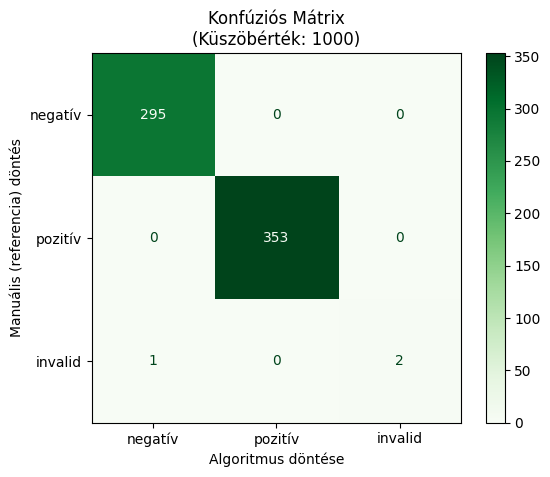

In [30]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív', 'invalid']
hpv_koczi_cm_sample = confusion_matrix(hpv_koczi_all_samples['minta_manual'], hpv_koczi_all_samples['minta'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=hpv_koczi_cm_sample, display_labels=labels)
disp.plot(cmap=plt.cm.Greens) # Zöld színskála a diagnosztikai siker jelzésére
plt.title(f'Konfúziós Mátrix\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_hpv_samples.png')
plt.show()

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(hpv_koczi_all_samples['minta'], hpv_koczi_all_samples['minta_manual'], 
      target_names=["invalid", "negatív", "pozitív"], digits = 4))

              precision    recall  f1-score   support

     invalid     0.6667    1.0000    0.8000         2
     negatív     1.0000    0.9966    0.9983       296
     pozitív     1.0000    1.0000    1.0000       353

    accuracy                         0.9985       651
   macro avg     0.8889    0.9989    0.9328       651
weighted avg     0.9990    0.9985    0.9986       651



### Negatív HPV minták belső kontroll ct értékei

In [32]:
ic_curves = all_result_hpv_melted[all_result_hpv_melted['dye']==  'CY5']
ic_curves.head()

,PCR,well_position,dye,dy_mean
1344,hpv_teszt_1,A1,CY5,333.041545
1345,hpv_teszt_1,A11,CY5,4698.660089
1346,hpv_teszt_1,A13,CY5,520.109517
1347,hpv_teszt_1,A15,CY5,4551.419058
1348,hpv_teszt_1,A17,CY5,159.595352


In [33]:
hpv_koczi_ic_curves_sample = pd.merge(ic_curves, hpv_sample, on=["PCR", "well_position"], how="left",suffixes=('', '_manual'))
hpv_koczi_ic_curves_sample.head()

,PCR,well_position,dye,dy_mean,well,minta,target,flag
0,hpv_teszt_1,A1,CY5,333.041545,1.0,pozitív,HPV 16,NaN
1,hpv_teszt_1,A11,CY5,4698.660089,11.0,negatív,NaN,NaN
2,hpv_teszt_1,A13,CY5,520.109517,13.0,pozitív,HPV 16,NaN
3,hpv_teszt_1,A15,CY5,4551.419058,15.0,negatív,NaN,NaN
4,hpv_teszt_1,A17,CY5,159.595352,17.0,pozitív,HPV 16,NaN


In [34]:
neg_samples = hpv_koczi_ic_curves_sample[hpv_koczi_ic_curves_sample['minta'] == 'negatív']
neg_samples.head()

,PCR,well_position,dye,dy_mean,well,minta,target,flag
1,hpv_teszt_1,A11,CY5,4698.660089,11.0,negatív,NaN,NaN
3,hpv_teszt_1,A15,CY5,4551.419058,15.0,negatív,NaN,NaN
5,hpv_teszt_1,A19,CY5,3783.202377,19.0,negatív,NaN,NaN
7,hpv_teszt_1,A23,CY5,3802.478616,23.0,negatív,NaN,NaN
8,hpv_teszt_1,A3,CY5,3920.424314,3.0,negatív,NaN,NaN


In [35]:
neg_samples[neg_samples['well_position']== 'O21']

,PCR,well_position,dye,dy_mean,well,minta,target,flag
90,hpv_teszt_1,O21,CY5,4418.763128,357.0,negatív,NaN,NaN
186,hpv_teszt_2,O21,CY5,1253.821060,357.0,negatív,NaN,NaN
282,hpv_teszt_3,O21,CY5,4469.306897,357.0,negatív,NaN,NaN
378,hpv_teszt_4,O21,CY5,4301.632014,357.0,negatív,NaN,NaN
474,hpv_teszt_5,O21,CY5,4482.378903,357.0,negatív,NaN,NaN
570,hpv_teszt_6,O21,CY5,3769.510117,357.0,negatív,NaN,NaN
666,hpv_teszt_7,O21,CY5,3975.692990,357.0,negatív,NaN,NaN


In [36]:
import plotly.express as px

fig = px.box(
    neg_samples,
    x="minta",
    y="dy_mean",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "VIC": "#7DA78C",
        "CY5": "#744577"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    title=dict(text="Első derivált átlaga Légúti panel kitben csatornák szerint", x=0.5),
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(range=[-1000, 6000])
)

fig.update_layout(
    title=dict(
        text="Belső kontroll első derivált átlag eloszlása HPV negatív mintákban",
        x=0.5
    )
)

fig.add_hline(
    y=1100,
    line_dash="dash",
    line_color="gray",
    annotation_text="threshold",
    annotation_position="top left")

fig.add_shape(
    type="line",
    xref="paper",   # ← EZ A LÉNYEG
    x0=0,
    x1=1,
    yref="y",
    y0=1000,
    y1=1000,
    line=dict(color="gray", width=2, dash="dash"))


fig.show()